In [1]:
from lokigi.site import SiteProblem

In [2]:
problem = SiteProblem()

In [3]:
problem.describe_models(available_only=True)

=== Supported Healthcare Location Models ===

ID: p_median
Name: P-Median (Average Distance Minimizer)
Goal: Minimize the total travel distance for the entire population.
When to use: Best for general primary care where you want the 'average' patient to have the shortest trip possible.
Main Trade-off: Can leave remote or rural patients with very long travel times in favor of urban density.

To run a model, use: prob.solve_pmedian(p=3) or similar.


In [4]:
problem.describe_models(available_only=False)

=== Healthcare Location Models ===

ID: p_median
Name: P-Median (Average Distance Minimizer)
Goal: Minimize the total travel distance for the entire population.
When to use: Best for general primary care where you want the 'average' patient to have the shortest trip possible.
Main Trade-off: Can leave remote or rural patients with very long travel times in favor of urban density.
Status: Supported

ID: mclp
Name: Maximal Coverage Location Problem (MCLP)
Goal: Maximize the number of people within a specific time/distance 'threshold' (e.g., 15 minutes).
When to use: Best for emergency services (Ambulance/ER) where getting there within a 'Golden Hour' is more important than the average trip time.
Main Trade-off: Does not care how far away people are once they are outside the threshold.
Status: Planned

ID: lscp
Name: Location Set Covering Location Problem (LSCP)
Goal: Find the minimum number of facilities needed to cover *everyone* within a certain distance.
When to use: Best for universa

In [5]:
problem.show_demand_format()


--- Expected Demand DataFrame Format ---
Note: Each row represents a unique demand location (e.g., LSOA).
site_id_col     | demand_col
------------------------------
LSOA 1          | 25        
LSOA 2          | 15        
...             | ...       
----------------------------------------



In [6]:
problem.show_travel_format()


--- Expected Travel/Cost DataFrame Format ---
Note: Rows are sources, columns are destinations.
source_id       | dest_1          | dest_2         
--------------------------------------------------
source_1        | 22.6            | 16.3           
source_2        | 15.1            | 17.1           
...             | ...             | ...            
--------------------------------------------

For example, if using LSOAs, your dataframe might look like this:
source_id       | E01000259       | E01000314      
--------------------------------------------------
Brighton and Hove 027E | 22.6            | 16.3           
Brighton and Hove 005C | 15.1            | 17.1           
...             | ...             | ...            
--------------------------------------------

Or if you've defined your site names, it might look like this:
source_id       | Site 1          | Site 1         
--------------------------------------------------
Brighton and Hove 027E | 22.6            | 16.3

## Add the required data

In [7]:
problem.add_demand("../../sample_data/brighton_demand.csv", demand_col="demand", location_id_col="LSOA")

In [8]:
problem.show_demand()

                       LSOA  demand
0    Brighton and Hove 027E    3627
1    Brighton and Hove 027F    2323
2    Brighton and Hove 027A    2596
3    Brighton and Hove 029E    3132
4    Brighton and Hove 029D    2883
..                      ...     ...
160  Brighton and Hove 012A    2497
161  Brighton and Hove 005C    2570
162  Brighton and Hove 012B    2051
163  Brighton and Hove 005A    1164
164  Brighton and Hove 005B    1097

[165 rows x 2 columns]


In [9]:
problem.add_sites("../../sample_data/brighton_sites.geojson", candidate_id_col="site")

In [10]:
problem.show_sites()

     site                       geometry
0  Site 1  POINT (527142.275 106616.053)
1  Site 2  POINT (531493.995 106639.488)
2  Site 3  POINT (533356.778 105476.782)
3  Site 4   POINT (528513.424 105052.43)
4  Site 5  POINT (532421.163 109069.196)
5  Site 6  POINT (528716.452 108042.794)


In [11]:
# problem.plot_sites()

In [12]:
problem.add_travel_matrix(
    travel_matrix_df="../../sample_data/brighton_travel_matrix_driving.csv",
    source_col="LSOA"
    )

In [13]:
problem.travel_matrix

,LSOA,Site 1,Site 2,Site 3,Site 4,Site 5,Site 6
0,Brighton and Hove 027E,773.93,527.69,444.29,491.85,607.54,554.91
1,Brighton and Hove 027F,757.39,499.11,517.57,561.07,578.97,538.37
2,Brighton and Hove 027A,763.24,601.38,517.98,410.40,681.23,557.35
3,Brighton and Hove 029E,743.62,651.72,660.36,379.72,731.58,557.58
4,Brighton and Hove 029D,665.85,664.65,658.20,313.00,744.50,570.51
...,...,...,...,...,...,...,...
160,Brighton and Hove 012A,446.54,884.70,1108.11,519.16,626.02,447.78
161,Brighton and Hove 005C,469.80,784.83,1008.24,569.40,526.15,347.91
162,Brighton and Hove 012B,464.53,909.18,1132.60,537.15,650.51,472.26
163,Brighton and Hove 005A,567.49,882.52,1105.93,664.11,623.84,445.60


In [14]:
# problem.add_region_geometry_layer("https://github.com/hsma-programme/h6_3d_facility_location_problems/raw/refs/heads/main/h6_3d_facility_location_problems/example_code/LSOA_2011_Boundaries_Super_Generalised_Clipped_BSC_EW_V4.geojson", common_col="LSOA11NM")

In [15]:
problem.add_region_geometry_layer("../../sample_data/LSOA_2011_Boundaries_Super_Generalised_Clipped_BSC_EW_V4.geojson", common_col="LSOA11NM")

In [16]:
# problem.region_geometry_layer

In [17]:
# problem.region_geometry_layer.plot()

In [18]:
combo_1 = problem.evaluate_single_solution_pmedian(site_names=["Site 1", "Site 2"])
combo_1

In [19]:
combo_1.generate_solution_metrics()

{'site_names': ['Site 1', 'Site 2'],
 'site_indices': array([0, 1]),
 'weighted_average': np.float64(507.04111202823384),
 'unweighted_average': np.float64(489.1475757575758),
 'max': np.float64(1435.26),
 'problem_df':                        LSOA                  LSOA_x  Site 1  Site 2  min_cost  \
 0    Brighton and Hove 027E  Brighton and Hove 027E  773.93  527.69    527.69   
 1    Brighton and Hove 027F  Brighton and Hove 027F  757.39  499.11    499.11   
 2    Brighton and Hove 027A  Brighton and Hove 027A  763.24  601.38    601.38   
 3    Brighton and Hove 029E  Brighton and Hove 029E  743.62  651.72    651.72   
 4    Brighton and Hove 029D  Brighton and Hove 029D  665.85  664.65    664.65   
 ..                      ...                     ...     ...     ...       ...   
 160  Brighton and Hove 012A  Brighton and Hove 012A  446.54  884.70    446.54   
 161  Brighton and Hove 005C  Brighton and Hove 005C  469.80  784.83    469.80   
 162  Brighton and Hove 012B  Brighton and 

In [20]:
combo_2 = problem.evaluate_single_solution_pmedian(site_indices=[1,2])
combo_2.evaluated_combination_df

,LSOA,LSOA_x,Site 2,Site 3,min_cost,LSOA_y,demand
0,Brighton and Hove 027E,Brighton and Hove 027E,527.69,444.29,444.29,Brighton and Hove 027E,3627
1,Brighton and Hove 027F,Brighton and Hove 027F,499.11,517.57,499.11,Brighton and Hove 027F,2323
2,Brighton and Hove 027A,Brighton and Hove 027A,601.38,517.98,517.98,Brighton and Hove 027A,2596
3,Brighton and Hove 029E,Brighton and Hove 029E,651.72,660.36,651.72,Brighton and Hove 029E,3132
4,Brighton and Hove 029D,Brighton and Hove 029D,664.65,658.20,658.20,Brighton and Hove 029D,2883
...,...,...,...,...,...,...,...
160,Brighton and Hove 012A,Brighton and Hove 012A,884.70,1108.11,884.70,Brighton and Hove 012A,2497
161,Brighton and Hove 005C,Brighton and Hove 005C,784.83,1008.24,784.83,Brighton and Hove 005C,2570
162,Brighton and Hove 012B,Brighton and Hove 012B,909.18,1132.60,909.18,Brighton and Hove 012B,2051
163,Brighton and Hove 005A,Brighton and Hove 005A,882.52,1105.93,882.52,Brighton and Hove 005A,1164


In [21]:
solutions = problem.solve_pmedian(p=3)
solutions.show_solutions()

,site_names,site_indices,weighted_average,unweighted_average,max,problem_df
0,None,"[2, 3, 4]",322.332474,326.870485,1001.33,LSOA L...
1,None,"[2, 3, 5]",322.617230,321.476485,1001.33,LSOA L...
2,None,"[0, 2, 3]",331.865526,340.352364,1001.33,LSOA L...
3,None,"[1, 2, 3]",332.643083,335.693030,1001.33,LSOA L...
4,None,"[0, 2, 5]",379.412569,372.784909,1001.33,LSOA L...
5,None,"[0, 2, 4]",381.167548,379.065091,1001.33,LSOA L...
6,None,"[2, 4, 5]",385.026650,377.342545,1001.33,LSOA L...
7,None,"[0, 1, 2]",388.228257,383.234000,1001.33,LSOA L...
8,None,"[1, 2, 5]",390.336132,378.580727,1001.33,LSOA L...
9,None,"[1, 3, 4]",415.429428,405.868970,1302.58,LSOA L...


<Axes: >

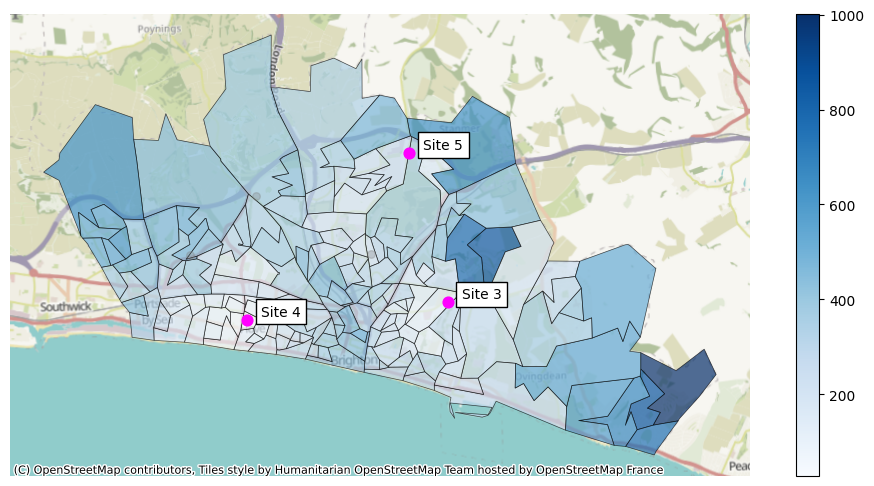

In [22]:
solutions.plot_best_combination(problem_class=problem)

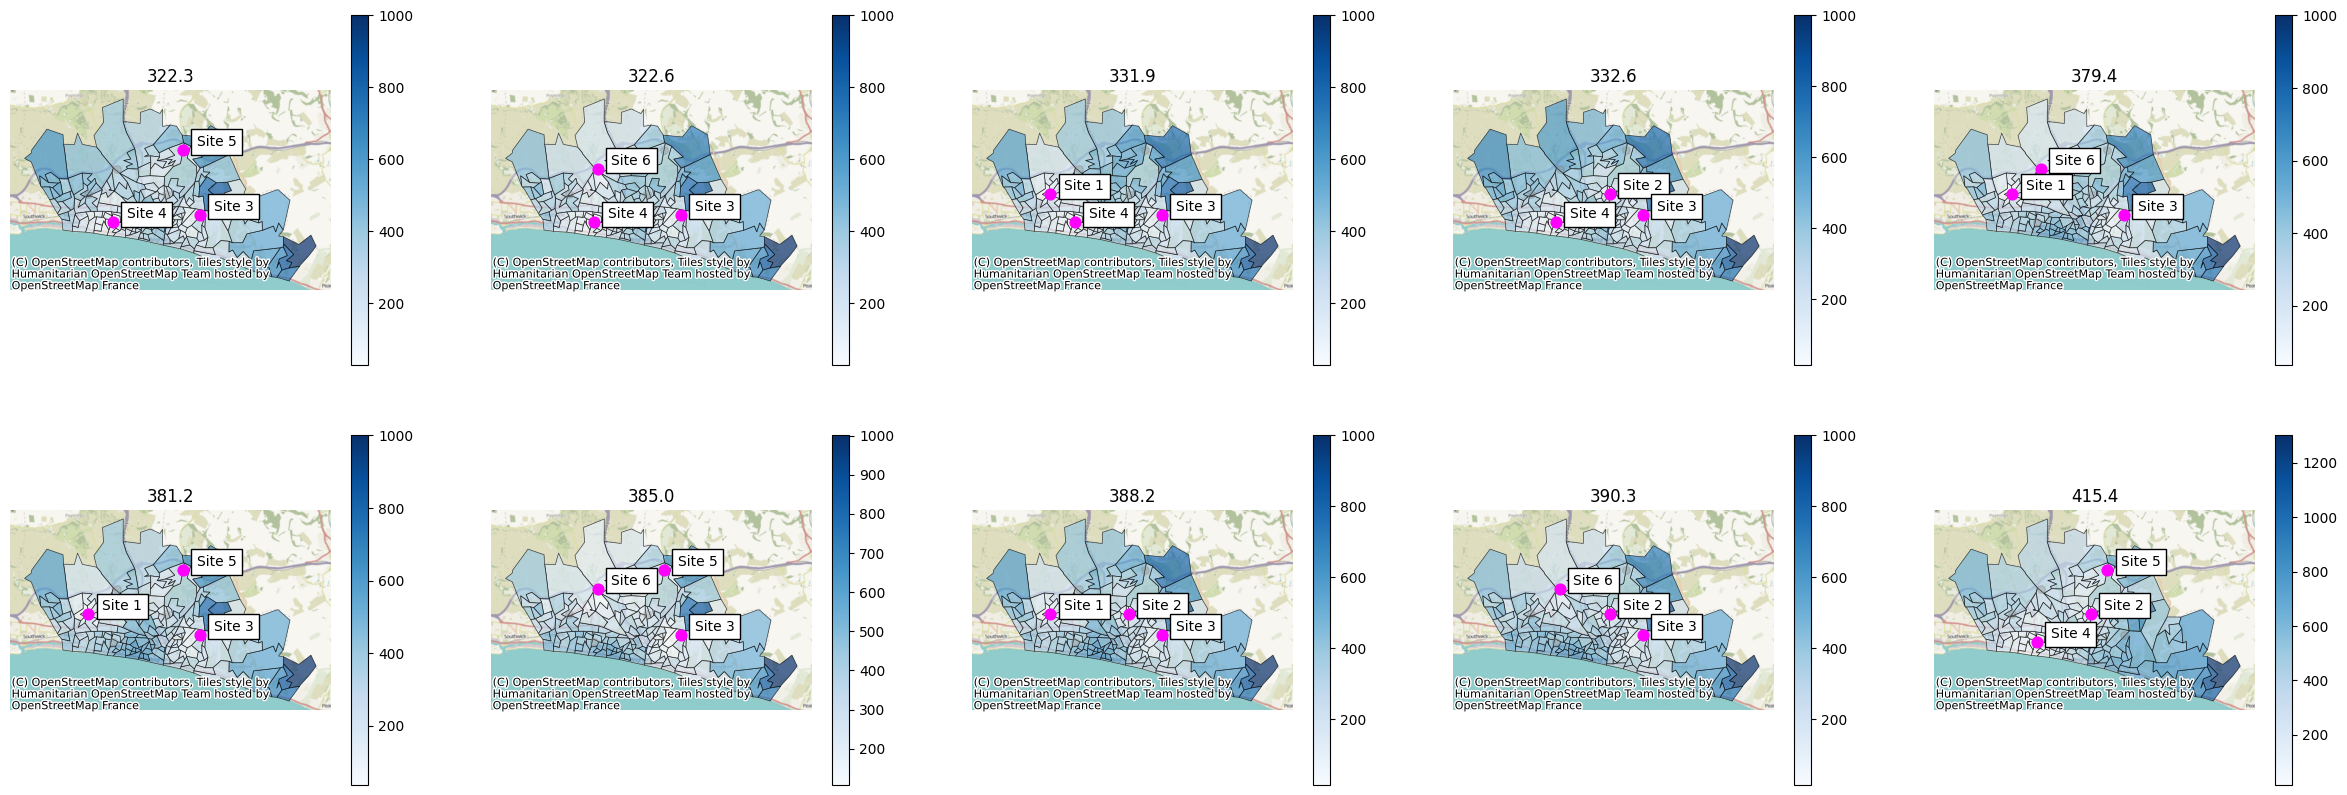

In [23]:
solutions.plot_n_best_combinations(problem_class=problem)

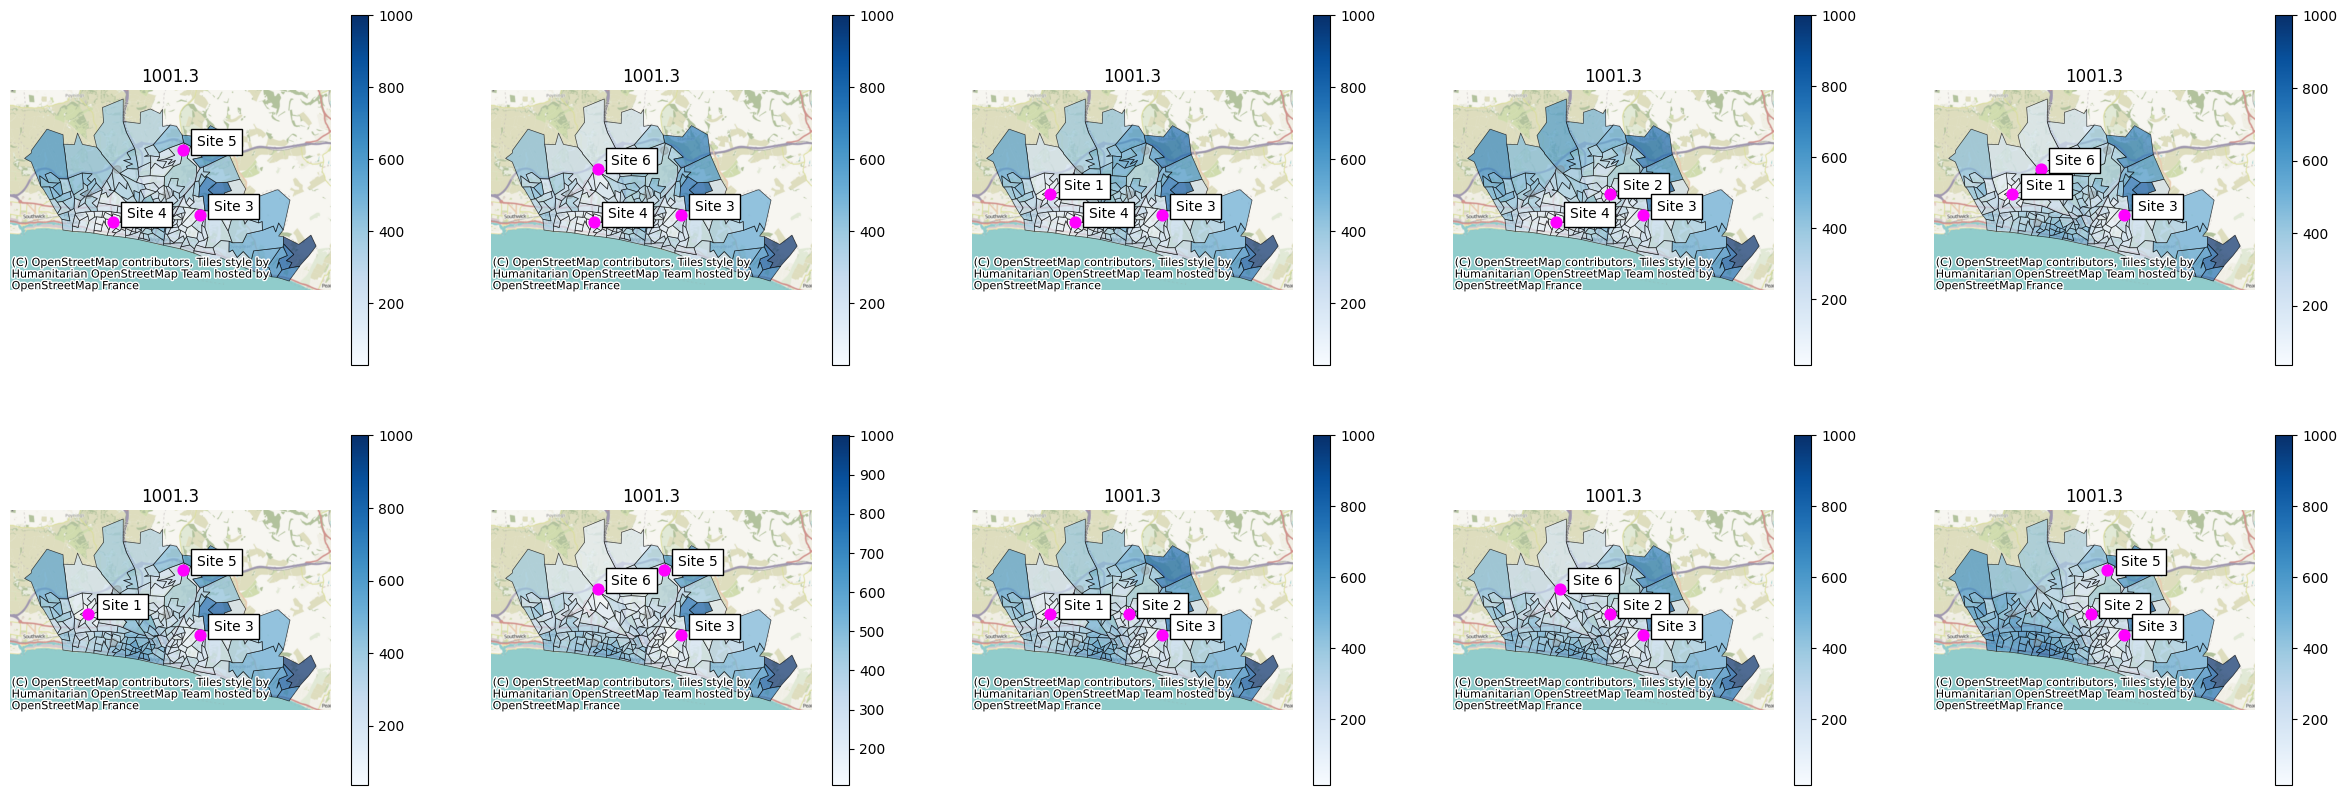

In [25]:
solutions.plot_n_best_combinations(problem_class=problem, rank_on="max", subplot_title="{solution['max'].values[0]:.1f}")